# DataFlow — Consultas MongoDB
## Colección: `pedidos`

Ejecutar **después** de correr `pipeline_etl.ipynb`.

Cada consulta demuestra una capacidad distinta de MongoDB:
- Consulta simple con `$match`
- Agrupaciones con `$group`
- Filtros compuestos
- Bucketing con `$bucket`
- Campos calculados en aggregation pipeline

In [1]:
import os
import pandas as pd
from pymongo import MongoClient
from dotenv import load_dotenv

load_dotenv('../.env')

client = MongoClient(os.getenv('MONGO_URI', 'mongodb://localhost:27017/'))
db  = client[os.getenv('MONGO_DB', 'dataflow')]
col = db[os.getenv('MONGO_COLLECTION', 'pedidos')]

print(f'Documentos en colección: {col.count_documents({}):,}')

Documentos en colección: 96,470


## Consulta 1: Conteo de pedidos tardíos vs a tiempo

In [2]:
pipeline = [
    {'$group': {
        '_id': '$entrega.tarde',
        'total': {'$sum': 1},
        'dias_promedio': {'$avg': '$entrega.dias_reales'}
    }},
    {'$sort': {'_id': 1}}
]

resultados = list(col.aggregate(pipeline))
df_q1 = pd.DataFrame(resultados)
df_q1['_id'] = df_q1['_id'].map({True: 'Tardío', False: 'A tiempo'})
df_q1.columns = ['Estado entrega', 'Total pedidos', 'Días promedio']
print('=== Consulta 1: Distribución de entregas ===')
display(df_q1)

=== Consulta 1: Distribución de entregas ===


,Estado entrega,Total pedidos,Días promedio
0,A tiempo,88644,10.419329
1,Tardío,7826,31.057884


## Consulta 2: Top 10 estados con más retrasos

In [3]:
pipeline = [
    {'$match': {'entrega.tarde': True}},
    {'$group': {
        '_id': '$cliente.estado',
        'total_tardios': {'$sum': 1},
        'dias_extra_promedio': {
            '$avg': {'$subtract': ['$entrega.dias_reales', '$entrega.dias_prometidos']}
        }
    }},
    {'$sort': {'total_tardios': -1}},
    {'$limit': 10}
]

df_q2 = pd.DataFrame(col.aggregate(pipeline))
df_q2.columns = ['Estado', 'Pedidos tardíos', 'Días extra promedio']
df_q2['Días extra promedio'] = df_q2['Días extra promedio'].round(1)
print('=== Consulta 2: Top 10 estados con más retrasos ===')
display(df_q2)

=== Consulta 2: Top 10 estados con más retrasos ===


,Estado,Pedidos tardíos,Días extra promedio
0,SP,2387,6.9
1,RJ,1664,12.7
2,MG,637,7.4
3,BA,457,11.0
4,RS,382,9.3
5,SC,346,7.6
6,PR,246,7.3
7,ES,244,10.5
8,CE,196,14.2
9,PE,172,11.2


## Consulta 3: Score promedio de reseñas por categoría de producto

In [4]:
pipeline = [
    {'$match': {'reseña.score': {'$gt': 0}}},  # excluir pedidos sin reseña
    {'$group': {
        '_id': '$producto.categoria',
        'score_promedio': {'$avg': '$reseña.score'},
        'total_reseñas': {'$sum': 1}
    }},
    {'$sort': {'score_promedio': 1}},
    {'$limit': 15}
]

df_q3 = pd.DataFrame(col.aggregate(pipeline))
df_q3.columns = ['Categoría', 'Score promedio', 'Total reseñas']
df_q3['Score promedio'] = df_q3['Score promedio'].round(2)
print('=== Consulta 3: Categorías con peor puntaje (asc) ===')
display(df_q3)

=== Consulta 3: Categorías con peor puntaje (asc) ===


,Categoría,Score promedio,Total reseñas
0,seguros_e_servicos,2.50,2
1,portateis_cozinha_e_preparadores_de_alimentos,3.62,13
2,moveis_escritorio,3.65,1229
3,fashion_roupa_masculina,3.82,104
4,pc_gamer,3.83,6
5,audio,3.85,341
6,casa_conforto_2,3.90,21
7,moveis_colchao_e_estofado,3.91,34
8,fashion_roupa_feminina,3.92,36
9,casa_conforto,3.92,366


## Consulta 4: Pedidos problemáticos (tarde Y score bajo)

In [5]:
# Filtro compuesto: tarde=True Y score <= 2
pipeline = [
    {'$match': {
        'entrega.tarde': True,
        'reseña.score': {'$lte': 2, '$gt': 0}
    }},
    {'$project': {
        'estado_pedido': 1,
        'cliente.estado': 1,
        'producto.categoria': 1,
        'entrega.dias_reales': 1,
        'entrega.dias_prometidos': 1,
        'reseña.score': 1,
        'reseña.titulo': 1
    }},
    {'$limit': 10}
]

resultados = list(col.aggregate(pipeline))
print(f'=== Consulta 4: Pedidos tardíos con score ≤ 2 ===')
print(f'Total encontrados: {col.count_documents({"entrega.tarde": True, "reseña.score": {"$lte": 2, "$gt": 0}}):,}')
for doc in resultados[:3]:
    print(f"  - Estado: {doc['cliente']['estado']} | Categoría: {doc['producto']['categoria']} | Score: {doc['reseña']['score']} | '{doc['reseña']['titulo']}'")

=== Consulta 4: Pedidos tardíos con score ≤ 2 ===
Total encontrados: 4,112
  - Estado: SP | Categoría: beleza_saude | Score: 1 | 'sin_reseña'
  - Estado: SP | Categoría: cama_mesa_banho | Score: 2 | 'sin_reseña'
  - Estado: SP | Categoría: beleza_saude | Score: 1 | 'sin_reseña'


## Consulta 5: Distribución de días reales de entrega ($bucket)

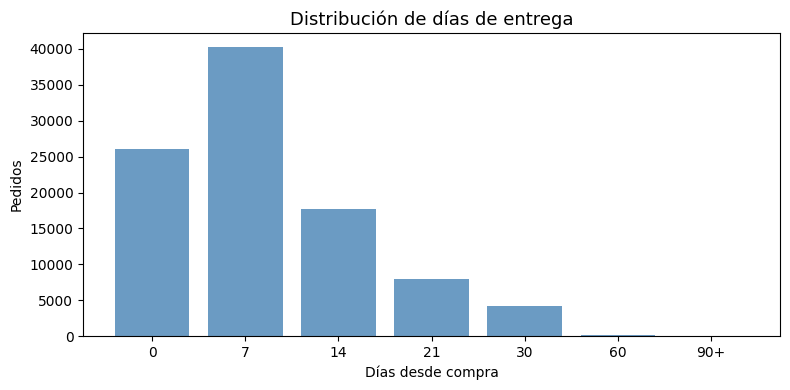

Consulta 5 completada ✓


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

pipeline = [
    {'$bucket': {
        'groupBy': '$entrega.dias_reales',
        'boundaries': [0, 7, 14, 21, 30, 60, 90],
        'default': '90+',
        'output': {'total': {'$sum': 1}}
    }}
]

df_q5 = pd.DataFrame(col.aggregate(pipeline))
df_q5.columns = ['Rango días', 'Total pedidos']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_q5['Rango días'].astype(str), df_q5['Total pedidos'], color='steelblue', alpha=0.8)
ax.set_title('Distribución de días de entrega', fontsize=13)
ax.set_xlabel('Días desde compra')
ax.set_ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../docs/distribucion_dias_entrega.png', dpi=120)
plt.show()
print('Consulta 5 completada ✓')

## Consulta 6: Vendedores con mayor tasa de retraso

In [7]:
pipeline = [
    {'$group': {
        '_id': '$vendedor.id',
        'total':         {'$sum': 1},
        'tardios':       {'$sum': {'$cond': ['$entrega.tarde', 1, 0]}},
        'estado_vendedor': {'$first': '$vendedor.estado'}
    }},
    {'$match': {'total': {'$gte': 20}}},  # mínimo 20 pedidos para ser representativo
    {'$sort': {'tardios': -1}},
    {'$limit': 10}
]

df_q6 = pd.DataFrame(col.aggregate(pipeline))
if df_q6.empty:
    print('Sin vendedores con 20+ pedidos en el dataset actual')
else:
    df_q6['pct_tardio'] = (df_q6['tardios'] / df_q6['total'] * 100).round(1)
    df_q6 = df_q6.sort_values('pct_tardio', ascending=False)
    df_q6['_id'] = df_q6['_id'].str[:8] + '...'  # truncar ID para display
    df_q6 = df_q6.rename(columns={'_id': 'Vendedor ID', 'total': 'Total', 'tardios': 'Tardíos',
                                    'estado_vendedor': 'Estado', 'pct_tardio': '% Tardío'})
    print('=== Consulta 6: Top 10 vendedores con mayor tasa de retraso ===')
    display(df_q6[['Vendedor ID', 'Estado', 'Total', 'Tardíos', '% Tardío']])

=== Consulta 6: Top 10 vendedores con mayor tasa de retraso ===


,Vendedor ID,Estado,Total,Tardíos,% Tardío
2,4869f7a5...,SP,1117,130,11.6
0,4a3ca931...,SP,1725,194,11.2
1,1f50f920...,SP,1384,148,10.7
3,ea8482cd...,SP,1122,118,10.5
9,8b321bb6...,SP,926,97,10.5
8,7c67e144...,SP,966,98,10.1
7,955fee92...,SP,1255,98,7.8
6,da8622b1...,SP,1295,100,7.7
4,6560211a...,SP,1810,116,6.4
5,cc419e06...,SP,1648,101,6.1
